In [1]:
import tensorflow as tf

# Enable GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from PID_implementation import *

# Load model and image folder

MODEL_PATH = "/Users/kadewidler/Desktop/widler_235585_original_unet_new_dataset_128px.h5"
IMAGE_FOLDER = "/Users/kadewidler/Desktop/Kaggle"

model = simple_unet_model(128, 128, 3)
model.load_weights(MODEL_PATH)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[f1])

/Users/kadewidler/Desktop/Y2B-2023-OT2_Twin/plant_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2026-01-15 16:27:54.247661: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-01-15 16:27:54.247680: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-15 16:27:54.247682: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-15 16:27:54.247754: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-15 16:27:54.248025: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:

**90 Degree rotation and X-Y swap to match SIM**

Analyzing 20 images to learn plant positions...
 4/17 [======>.......................] - ETA: 0s

2026-01-15 16:27:57.793018: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


17/17 [==============================] - 0s 23ms/step
✓ Learned positions from 13 images
  Average X-positions: ['1113.6', '1617.3', '2137.8', '2658.6', '3155.4']

Processing: test_image_01.png
17/17 [==============================] - 0s 23ms/step
Detected: 4/5
Crop offset: (721, 42, 2823, 2823)
Cropped size: (2823, 2823)
  Pos 1: ✅ → Sim (0.1651, 0.0788, 0.175)
  Pos 2: ✅ → Sim (0.1898, 0.1127, 0.175)
  Pos 4: ✅ → Sim (0.2031, 0.1686, 0.175)
  Pos 5: ✅ → Sim (0.2031, 0.1959, 0.175)


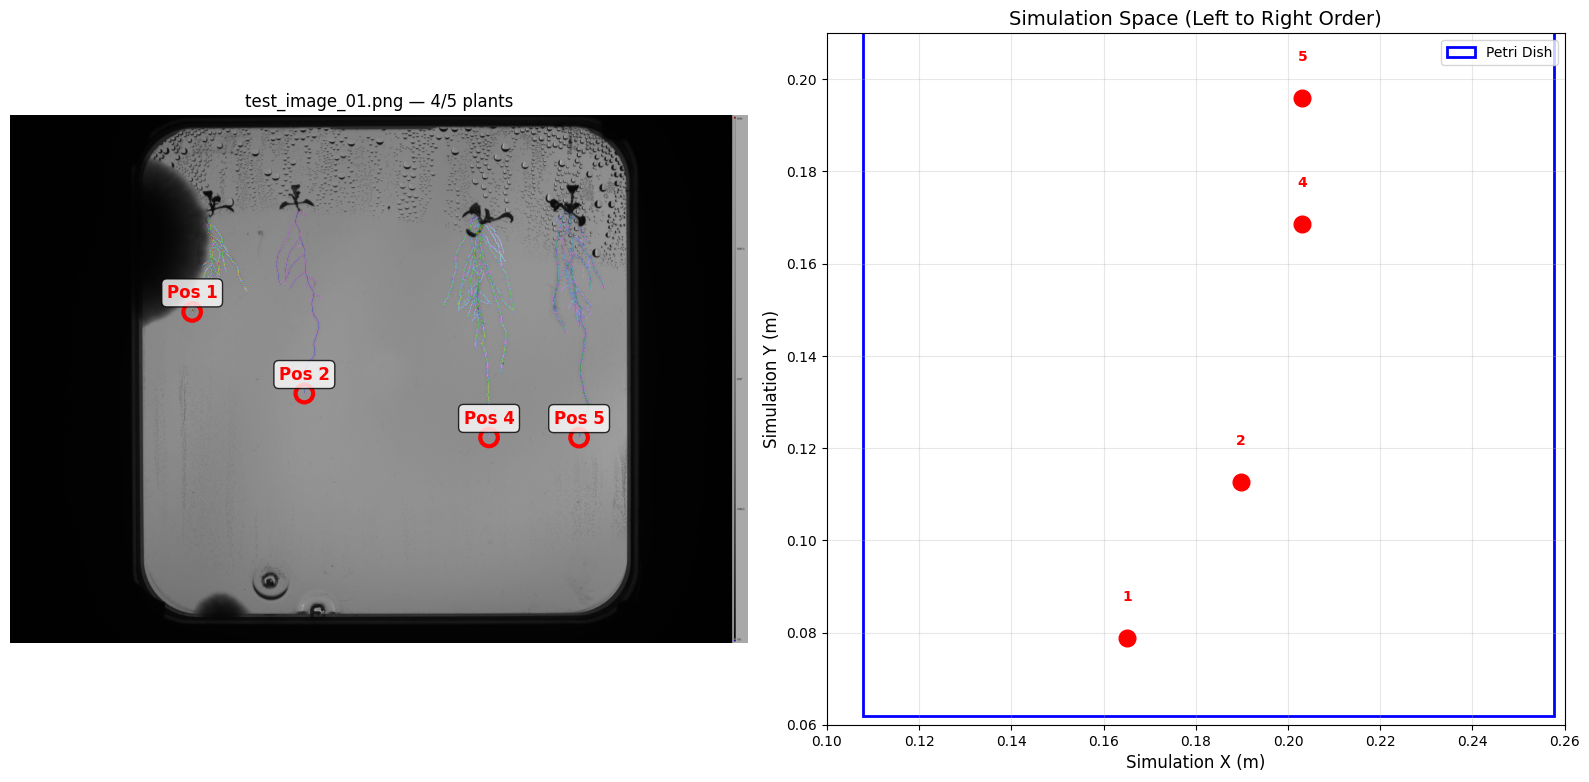


Processing: test_image_02.png
17/17 [==============================] - 0s 25ms/step
Detected: 5/5
Crop offset: (720, 42, 2824, 2823)
Cropped size: (2823, 2824)
  Pos 1: ✅ → Sim (0.1835, 0.0864, 0.175)
  Pos 2: ✅ → Sim (0.1869, 0.1073, 0.175)
  Pos 3: ✅ → Sim (0.1783, 0.1361, 0.175)
  Pos 4: ✅ → Sim (0.1802, 0.1554, 0.175)
  Pos 5: ✅ → Sim (0.1812, 0.1865, 0.175)


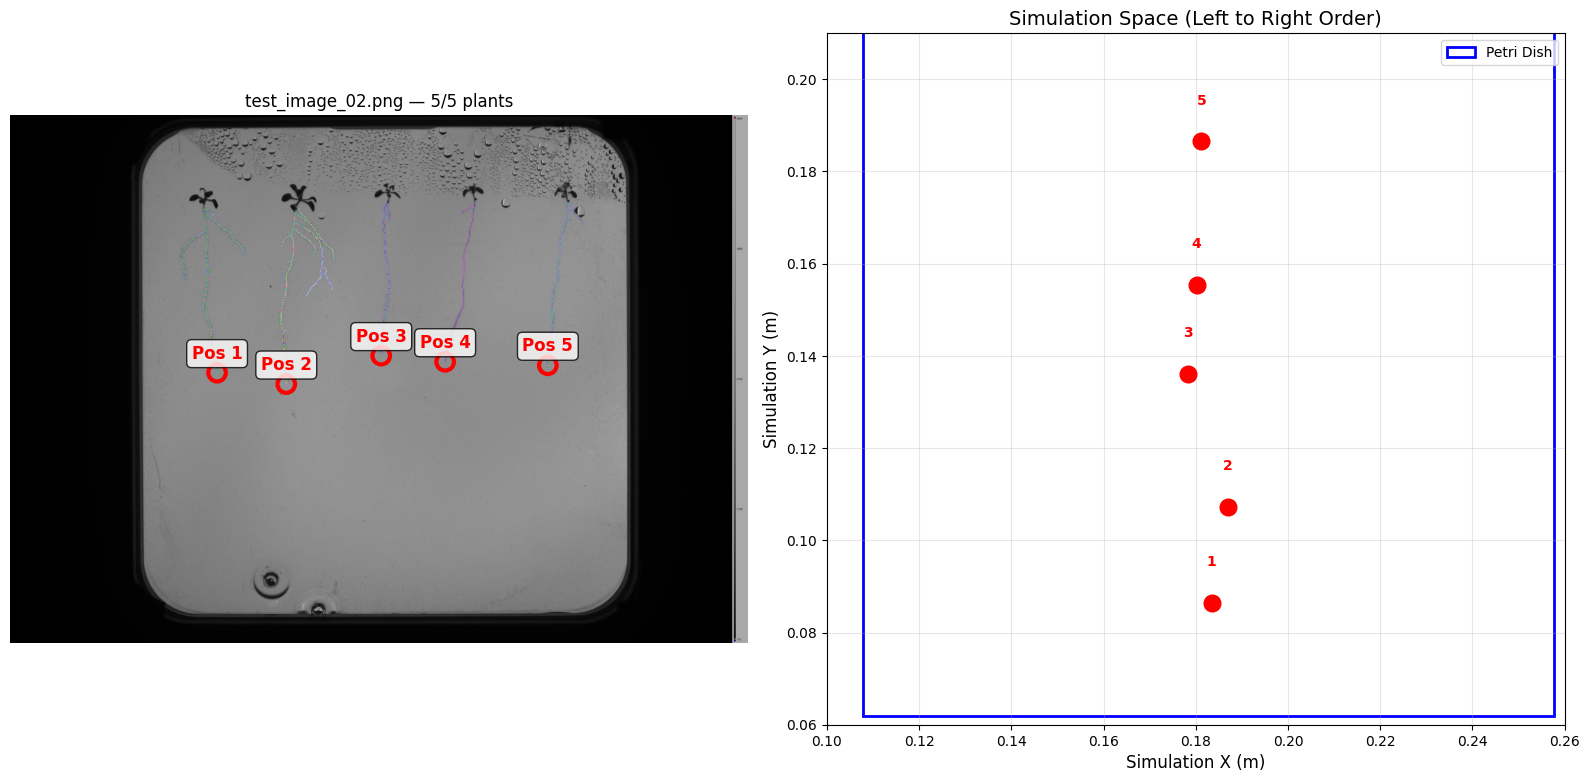


Processing: test_image_03.png
17/17 [==============================] - 0s 23ms/step
Detected: 2/5
Crop offset: (721, 39, 2822, 2826)
Cropped size: (2826, 2822)
  Pos 2: ✅ → Sim (0.1396, 0.1102, 0.175)
  Pos 4: ✅ → Sim (0.1393, 0.1642, 0.175)


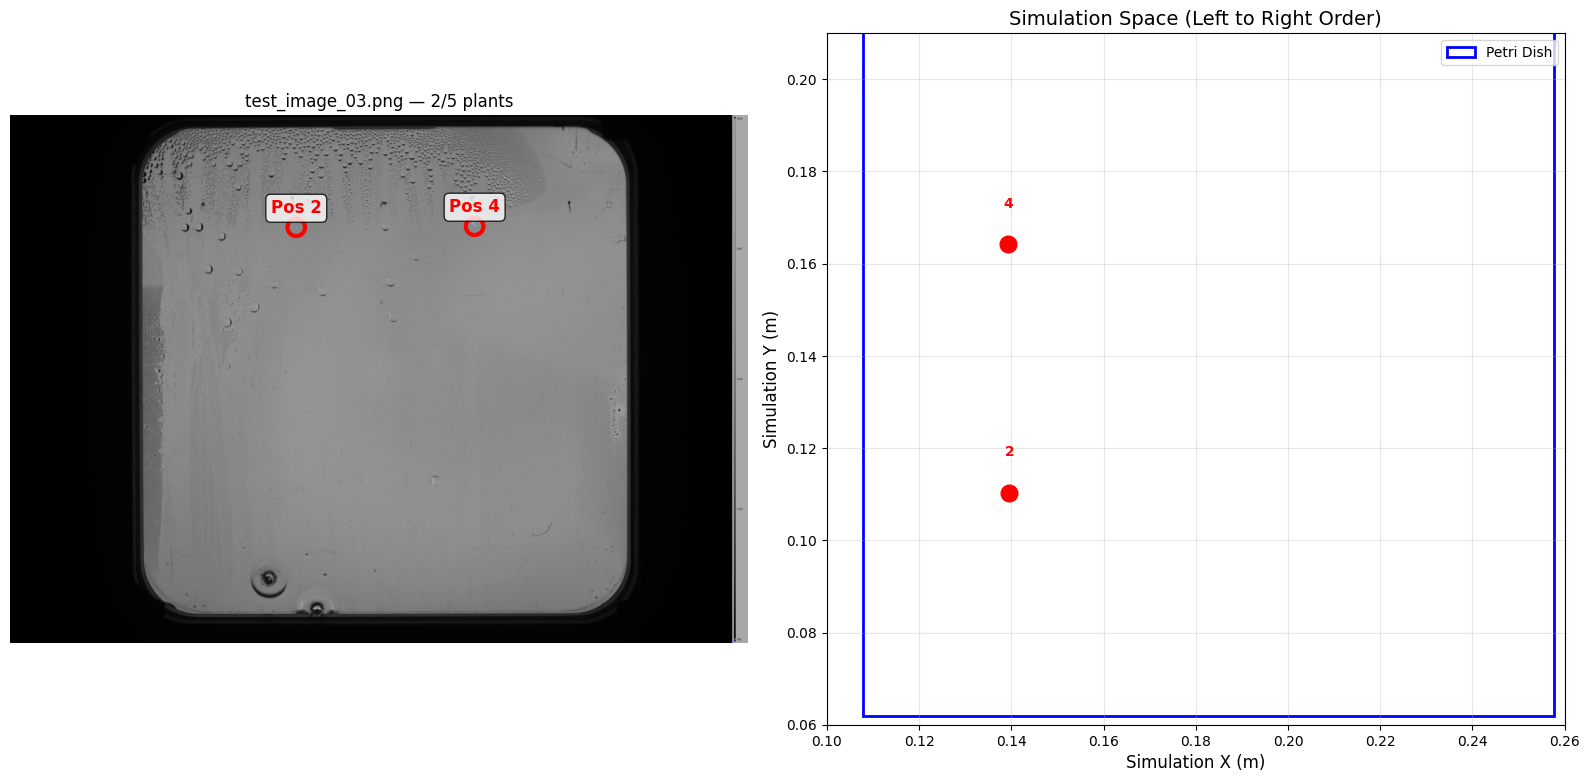

In [2]:
# Learn Positions and Test

avg_positions = learn_plant_positions(IMAGE_FOLDER, model)
zone_boundaries = create_zone_boundaries(avg_positions)

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith(('.jpg', '.png', '.jpeg', '.tif'))
])

# Test first 3 images
for img_name in image_files[:3]:
    test_img_path = os.path.join(IMAGE_FOLDER, img_name)
    print(f"\nProcessing: {img_name}")

    plant_mask, position_coords, metadata = process_image_with_positions(
        test_img_path,
        model,
        zone_boundaries,
        return_coords=True
    )

    print(f"Detected: {sum(c is not None for c in position_coords)}/5")
    print(f"Crop offset: {metadata['crop_coords']}")
    print(f"Cropped size: {metadata['cropped_shape']}")

    pixel_size = metadata['cropped_shape'][0]
    mapper = PetriDishMapper(pixel_size)

    for pos_idx, coords in enumerate(position_coords, 1):
        if coords is not None:
            sx, sy, sz = mapper.pixel_to_sim(coords[0], coords[1])
            valid = "✅" if mapper.validate_coords(sx, sy, sz) else "❌"
            print(f"  Pos {pos_idx}: {valid} → Sim ({sx:.4f}, {sy:.4f}, {sz:.3f})")

    visualize_root_tips(
        test_img_path,
        plant_mask,
        position_coords,
        metadata
    )